In [1]:
# ==========================================
# 0. 导包
# ==========================================
import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

from lifelines import WeibullFitter, CoxTimeVaryingFitter

import matplotlib.pyplot as plt

d:\Anaconda\envs\python3.10.11\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
# ==========================================
# 1. 读文件（FD001 train）
# ==========================================
index_names = ['unit_nr', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'SM{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# 你新 notebook 里建议直接用这个（你已上传了 train_FD001.txt）
file_path = 'CMAPSSData/train_FD001.txt'   # 如果你放在 CMAPSSData/train_FD001.txt，就改成那个路径
df = pd.read_csv(file_path, sep=r'\s+', header=None, names=col_names)

print("Loaded:", df.shape)
print(df.head())

Loaded: (20631, 26)
   unit_nr  time_cycles  setting_1  setting_2  setting_3     SM1     SM2  \
0        1            1    -0.0007    -0.0004      100.0  518.67  641.82   
1        1            2     0.0019    -0.0003      100.0  518.67  642.15   
2        1            3    -0.0043     0.0003      100.0  518.67  642.35   
3        1            4     0.0007     0.0000      100.0  518.67  642.35   
4        1            5    -0.0019    -0.0002      100.0  518.67  642.37   

       SM3      SM4    SM5  ...    SM12     SM13     SM14    SM15  SM16  SM17  \
0  1589.70  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03   392   
1  1591.82  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03   392   
2  1587.99  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03   390   
3  1582.79  1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03   392   
4  1582.85  1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03   393   

   SM18   SM19   SM20     SM21  
0  

In [4]:
# ==========================================
# 2. 选择论文 14 个传感器
# ==========================================
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

df_process = df[index_names + selected_features].copy()

In [5]:
# ==========================================
# 3. Min-Max 归一化（全训练集口径）
# ==========================================
scaler = MinMaxScaler()
df_process[selected_features] = scaler.fit_transform(df_process[selected_features])

print("MinMax done.")

MinMax done.


In [6]:
# ==========================================
# 4. 构建 lifelines CoxTimeVaryingFitter 所需长表
#    start=t-1, stop=t，最后一个cycle event=1
# ==========================================
df_process['start'] = df_process['time_cycles'] - 1
df_process['stop']  = df_process['time_cycles']

max_cycles = df_process.groupby('unit_nr')['time_cycles'].max()

df_process['E'] = (df_process['time_cycles'] == df_process['unit_nr'].map(max_cycles)).astype(int)

print("Long format done:",
      "rows =", len(df_process),
      "units =", df_process['unit_nr'].nunique())
print(df_process[['unit_nr','time_cycles','start','stop','E']].head())

Long format done: rows = 20631 units = 100
   unit_nr  time_cycles  start  stop  E
0        1            1      0     1  0
1        1            2      1     2  0
2        1            3      2     3  0
3        1            4      3     4  0
4        1            5      4     5  0


In [7]:
# ==========================================
# 5. 拟合 Weibull（得到 BH 参数 β, η）
#    使用每台发动机寿命 T = max_cycle，FD001 train 为 run-to-failure => E=1
# ==========================================
durations = max_cycles.values.astype(float)
events = np.ones_like(durations, dtype=int)

wb = WeibullFitter()
wb.fit(durations=durations, event_observed=events)

beta = float(wb.rho_)      # shape
eta  = float(wb.lambda_)   # scale

print("\nWeibull fitted:")
print("beta (shape) =", beta)
print("eta  (scale) =", eta)

# 计算每一行的 Baseline Hazard BH(t) = (beta/eta) * (t/eta)^(beta-1)
t = df_process['time_cycles'].astype(float).values
BH = (beta / eta) * (t / eta) ** (beta - 1.0)
df_process['BH'] = BH


Weibull fitted:
beta (shape) = 4.408714937980028
eta  (scale) = 225.02585413831693


In [8]:
# ==========================================
# 6. 拟合 time-varying Cox（得到 HR）
#    关键：predict_partial_hazard 只喂 14 个传感器列
# ==========================================
ctv = CoxTimeVaryingFitter(penalizer=0.0)  # 若你觉得不稳定可改 1e-3 或 1e-2
ctv.fit(
    df_process[['unit_nr','start','stop','E'] + selected_features],
    id_col='unit_nr',
    start_col='start',
    stop_col='stop',
    event_col='E',
    show_progress=True
)

print("\nCox TV fitted. Top params:")
print(ctv.params_.sort_values(ascending=False))

HR = ctv.predict_partial_hazard(df_process[selected_features]).values.astype(float)
df_process['HR'] = HR

# hazard_rate（可选，后续不用于聚类）
df_process['hazard_rate'] = df_process['BH'] * df_process['HR']

Iteration 1: norm_delta = 1.00e+00, step_size = 0.9500, log_lik = -363.73938, newton_decrement = 1.69e+02, seconds_since_start = 0.0
Iteration 2: norm_delta = 1.23e+00, step_size = 0.9500, log_lik = -196.95744, newton_decrement = 6.53e+01, seconds_since_start = 0.0
Iteration 3: norm_delta = 7.49e-01, step_size = 0.9500, log_lik = -141.32406, newton_decrement = 2.53e+01, seconds_since_start = 0.0
Iteration 4: norm_delta = 7.27e-01, step_size = 0.9310, log_lik = -129.43964, newton_decrement = 1.68e+01, seconds_since_start = 0.0
Iteration 5: norm_delta = 2.30e-01, step_size = 1.0000, log_lik = -115.92018, newton_decrement = 1.13e+00, seconds_since_start = 0.1
Iteration 6: norm_delta = 4.04e-02, step_size = 1.0000, log_lik = -114.78357, newton_decrement = 1.24e-02, seconds_since_start = 0.1
Iteration 7: norm_delta = 5.62e-04, step_size = 1.0000, log_lik = -114.77107, newton_decrement = 2.21e-06, seconds_since_start = 0.1
Iteration 8: norm_delta = 1.18e-07, step_size = 1.0000, log_lik = -11

In [9]:
# ==========================================
# 7. 构造聚类输入：BH + log(HR)
#    用 log(HR) 是为了抑制指数爆炸；然后做 MinMax scaling
# ==========================================
logHR = np.log(df_process['HR'].values + 1e-12)
df_process['logHR'] = logHR

# scaling（全体样本口径）
bh_scaler = MinMaxScaler()
hr_scaler = MinMaxScaler()

df_process['BH_scaled'] = bh_scaler.fit_transform(df_process[['BH']]).ravel()
df_process['logHR_scaled'] = hr_scaler.fit_transform(df_process[['logHR']]).ravel()

print("\nScaled features ready:")
print(df_process[['BH','HR','logHR','BH_scaled','logHR_scaled']].head())


Scaled features ready:
             BH        HR     logHR     BH_scaled  logHR_scaled
0  1.879273e-10  0.001544 -6.473092  0.000000e+00      0.242492
1  1.995792e-09  0.004167 -5.480498  1.825021e-08      0.270472
2  7.949873e-09  0.000781 -7.154796  7.835607e-08      0.223276
3  2.119536e-08  0.000257 -8.267140  2.120679e-07      0.191921
4  4.535021e-08  0.004510 -5.401533  4.559088e-07      0.272697


In [10]:
# ==========================================
# 8. KMeans：分别对 BH_scaled 与 logHR_scaled 做 2 类聚类（论文结构）
#    目标：输出 BH_state ∈ {0(low),1(high)}，HR_state ∈ {0(low),1(high)}
# ==========================================
def kmeans_2class_high_is_1(x_1d, random_state=42):
    """
    对一维特征做 KMeans(2类)，并强制：均值更大的那类记为 1（高风险），更小为 0（低风险）
    """
    x_1d = np.asarray(x_1d).reshape(-1, 1)
    km = KMeans(n_clusters=2, random_state=random_state, n_init='auto')
    labels = km.fit_predict(x_1d)
    centers = km.cluster_centers_.ravel()

    high_cluster = int(np.argmax(centers))
    # 映射到 {0,1} 且 high=1
    labels_high1 = (labels == high_cluster).astype(int)
    return labels_high1, km

df_process['BH_state'], km_bh = kmeans_2class_high_is_1(df_process['BH_scaled'].values)
df_process['HR_state'], km_hr = kmeans_2class_high_is_1(df_process['logHR_scaled'].values)

print("\nKMeans centers:")
print("BH centers:", km_bh.cluster_centers_.ravel())
print("HR centers:", km_hr.cluster_centers_.ravel())

print(df_process[['BH_scaled','logHR_scaled','BH_state','HR_state']].head())


KMeans centers:
BH centers: [0.03046377 0.33638692]
HR centers: [0.63665418 0.31503978]
      BH_scaled  logHR_scaled  BH_state  HR_state
0  0.000000e+00      0.242492         0         0
1  1.825021e-08      0.270472         0         0
2  7.835607e-08      0.223276         0         0
3  2.120679e-07      0.191921         0         0
4  4.559088e-07      0.272697         0         0


In [11]:
# ==========================================
# 9. 合成 3 类健康状态（论文规则）
#    Healthy=2, Warning=1, Failure=0
# ==========================================
def combine_state(bh_state, hr_state):
    # bh_state, hr_state: 0(low) or 1(high)
    if bh_state == 0 and hr_state == 0:
        return 2  # Healthy
    if bh_state == 1 and hr_state == 1:
        return 0  # Failure
    return 1      # Warning

df_process['Health'] = [
    combine_state(bh, hr) for bh, hr in zip(df_process['BH_state'], df_process['HR_state'])
]

print("\nHealth label counts:")
print(df_process['Health'].value_counts().sort_index())


Health label counts:
Health
0     1152
1     5976
2    13503
Name: count, dtype: int64


In [12]:
# ==========================================
# 10. 强制末段 failure（论文有这一手；d 论文未明说，先用 5）
# ==========================================
d = 5
for unit in df_process['unit_nr'].unique():
    idx = (df_process[df_process['unit_nr'] == unit]
           .sort_values('time_cycles')
           .tail(d)
           .index)
    df_process.loc[idx, 'Health'] = 0

print("\nHealth label counts after tail-forcing:")
print(df_process['Health'].value_counts().sort_index())


Health label counts after tail-forcing:
Health
0     1520
1     5608
2    13503
Name: count, dtype: int64


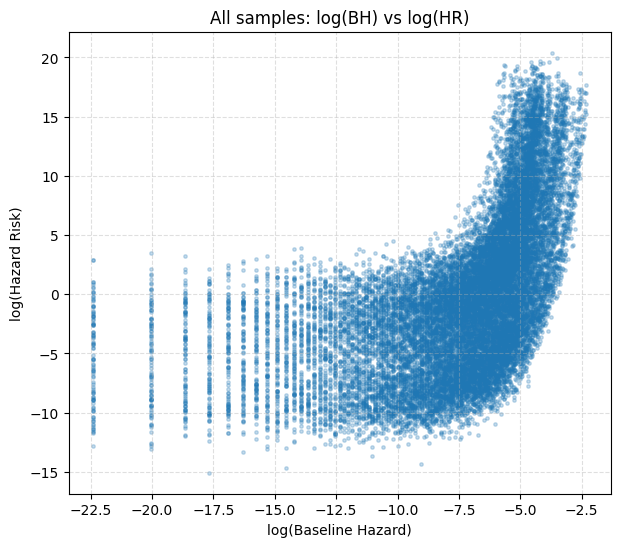

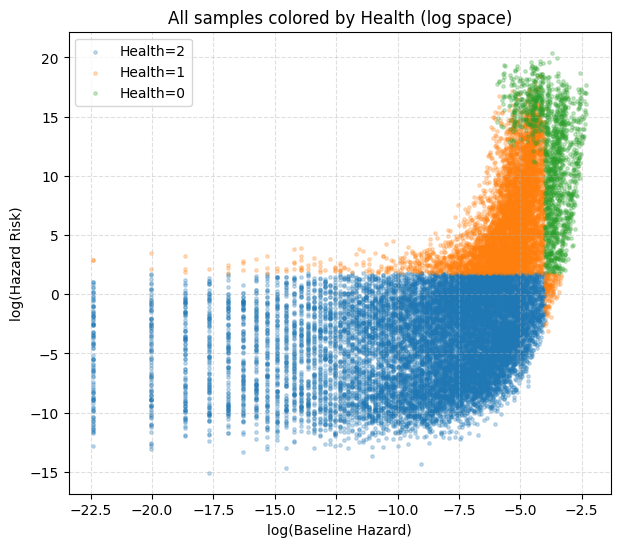

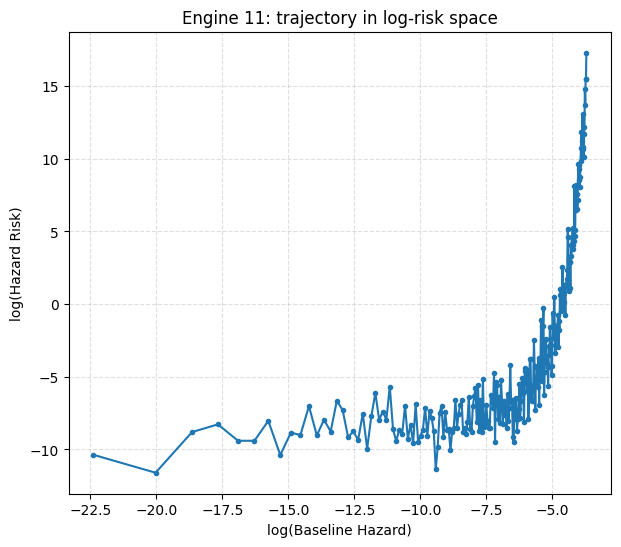

In [15]:
# ==========================================
# 11. 可视化：BH_scaled vs logHR_scaled（全体点 + 选定 engine）
# ==========================================
# 全体散点
plt.figure(figsize=(7, 6))
plt.scatter(
    np.log(df_process['BH'] + 1e-30),
    np.log(df_process['HR'] + 1e-12),
    s=6,
    alpha=0.25
)
plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title("All samples: log(BH) vs log(HR)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


# 按健康状态着色（颜色不指定也行，但这里为了区分更直观）
plt.figure(figsize=(7, 6))
for label in [2, 1, 0]:
    sub = df_process[df_process['Health'] == label]
    plt.scatter(
        np.log(sub['BH'] + 1e-30),
        np.log(sub['HR'] + 1e-12),
        s=6,
        alpha=0.25,
        label=f"Health={label}"
    )

plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title("All samples colored by Health (log space)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()


# 单独看 Engine 11 的轨迹
engine_id = 11
sub11 = df_process[df_process['unit_nr'] == engine_id].sort_values('time_cycles')

plt.figure(figsize=(7, 6))
plt.plot(
    np.log(sub11['BH'] + 1e-30),
    np.log(sub11['HR'] + 1e-12),
    linewidth=1.5,
    marker='o',
    markersize=3
)

plt.xlabel("log(Baseline Hazard)")
plt.ylabel("log(Hazard Risk)")
plt.title(f"Engine {engine_id}: trajectory in log-risk space")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


In [14]:
df_process.groupby('Health')[['BH','HR']].median()


,BH,HR
Health,,
0,0.025104,175920.787084
1,0.005260,232.376433
2,0.000384,0.027880


# 监督学习

In [16]:
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt


# 14 个传感器
selected_features = [
    'SM2','SM3','SM4','SM7','SM8','SM9','SM11',
    'SM12','SM13','SM14','SM15','SM17','SM20','SM21'
]

# 监督学习输入/标签/分组
X = df_process[selected_features].values
y = df_process['Health'].values.astype(int)
groups = df_process['unit_nr'].values  # 按发动机分组切分（关键）

print("X shape:", X.shape, "y dist:", pd.Series(y).value_counts().sort_index().to_dict())
print("n_engines:", df_process['unit_nr'].nunique())


X shape: (20631, 14) y dist: {0: 1520, 1: 5608, 2: 13503}
n_engines: 100


In [17]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
g_train, g_test = groups[train_idx], groups[test_idx]

print("train engines:", len(np.unique(g_train)), "test engines:", len(np.unique(g_test)))
print("train y dist:", pd.Series(y_train).value_counts().sort_index().to_dict())
print("test  y dist:", pd.Series(y_test).value_counts().sort_index().to_dict())


train engines: 80 test engines: 20
train y dist: {0: 1227, 1: 4409, 2: 10925}
test  y dist: {0: 293, 1: 1199, 2: 2578}


In [18]:
clf_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", multi_class="auto"))
])

clf_lr.fit(X_train, y_train)
pred_lr = clf_lr.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, pred_lr, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_lr))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0     0.4783    0.8294    0.6067       293
           1     0.8828    0.7790    0.8276      1199
           2     1.0000    0.9713    0.9854      2578

    accuracy                         0.9044      4070
   macro avg     0.7870    0.8599    0.8066      4070
weighted avg     0.9279    0.9044    0.9117      4070

Confusion matrix:
 [[ 243   50    0]
 [ 265  934    0]
 [   0   74 2504]]


In [19]:
clf_rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1,
    max_depth=None
)

clf_rf.fit(X_train, y_train)
pred_rf = clf_rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, pred_rf, digits=4))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_rf))


=== Random Forest ===
              precision    recall  f1-score   support

           0     0.7329    0.3652    0.4875       293
           1     0.8354    0.9183    0.8749      1199
           2     0.9770    0.9876    0.9823      2578

    accuracy                         0.9224      4070
   macro avg     0.8484    0.7570    0.7815      4070
weighted avg     0.9177    0.9224    0.9150      4070

Confusion matrix:
 [[ 107  185    1]
 [  39 1101   59]
 [   0   32 2546]]


SM11    0.149764
SM4     0.134586
SM12    0.133564
SM20    0.084720
SM7     0.083636
SM15    0.068484
SM21    0.063664
SM2     0.052945
SM9     0.052564
SM14    0.050220
SM3     0.041494
SM13    0.030568
SM8     0.027854
SM17    0.025939
dtype: float64


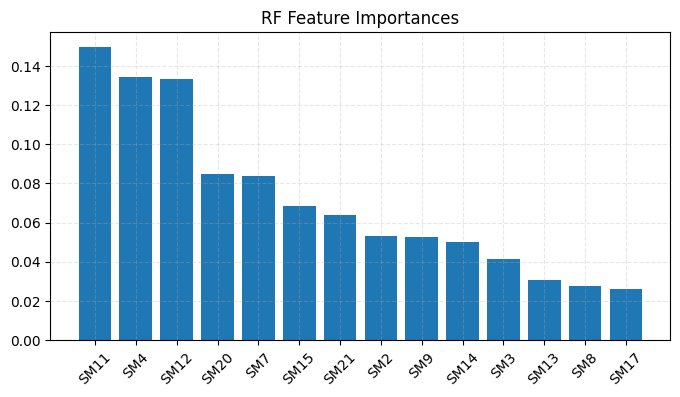

In [20]:
importances = pd.Series(clf_rf.feature_importances_, index=selected_features).sort_values(ascending=False)
print(importances)

plt.figure(figsize=(8,4))
plt.bar(importances.index, importances.values)
plt.xticks(rotation=45)
plt.title("RF Feature Importances")
plt.grid(True, linestyle="--", alpha=0.3)
plt.show()


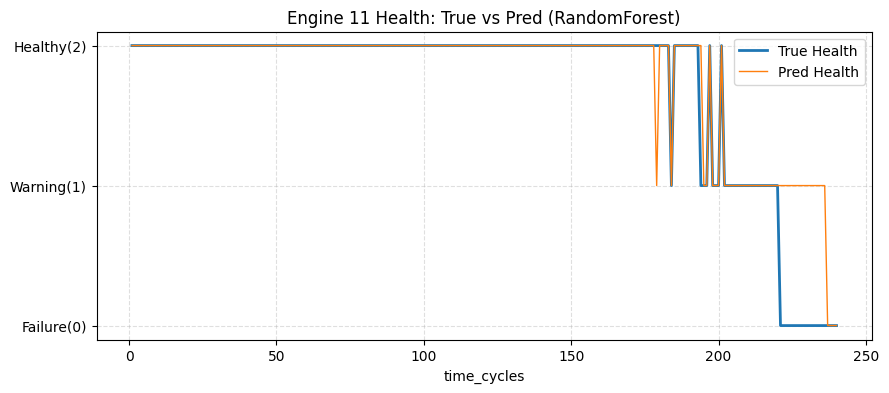

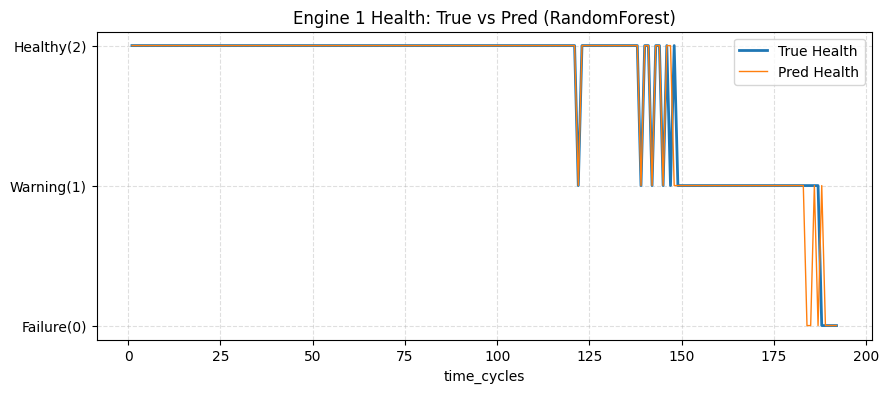

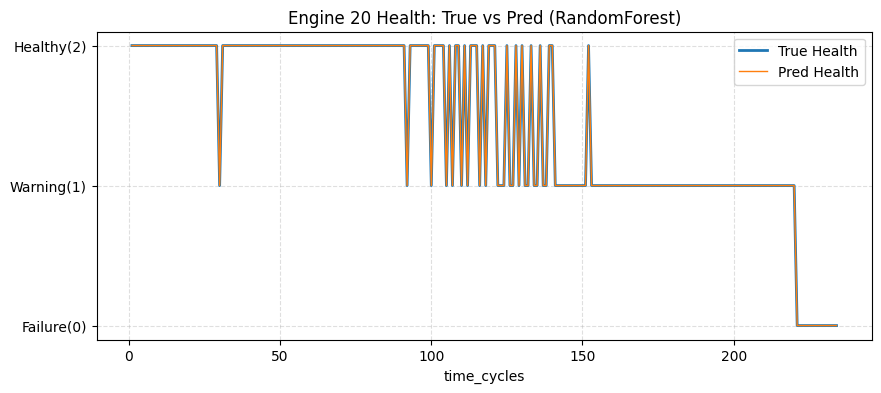

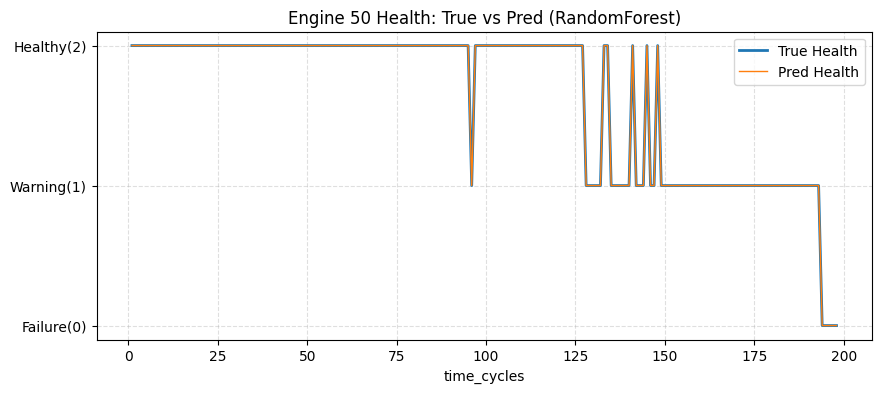

In [21]:
def plot_engine_pred(engine_id, model, title_suffix=""):
    sub = df_process[df_process["unit_nr"] == engine_id].sort_values("time_cycles")
    X_sub = sub[selected_features].values
    y_true = sub["Health"].values.astype(int)
    y_pred = model.predict(X_sub)

    plt.figure(figsize=(10,4))
    plt.plot(sub["time_cycles"], y_true, label="True Health", linewidth=2)
    plt.plot(sub["time_cycles"], y_pred, label="Pred Health", linewidth=1)
    plt.yticks([0,1,2], ["Failure(0)","Warning(1)","Healthy(2)"])
    plt.xlabel("time_cycles")
    plt.title(f"Engine {engine_id} Health: True vs Pred {title_suffix}")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.show()

# 选几个发动机看看（包含 11）
for eid in [11, 1, 20, 50]:
    plot_engine_pred(eid, clf_rf, "(RandomForest)")


In [22]:
# ======== 强制对齐论文的 state 编码 ========
# paper: 0=Healthy, 1=Warning, 2=Failure

health_map = {
    2: 0,  # Healthy -> 0
    1: 1,  # Warning -> 1
    0: 2   # Failure -> 2
}

df_process['Health_RL'] = df_process['Health'].map(health_map).astype(int)

print("Health (old) -> Health_RL (paper-aligned) counts:")
print(df_process[['Health', 'Health_RL']].value_counts().sort_index())


Health (old) -> Health_RL (paper-aligned) counts:
Health  Health_RL
0       2             1520
1       1             5608
2       0            13503
Name: count, dtype: int64
